<a href="https://colab.research.google.com/github/DavidArroyoTorres/python-ml-course/blob/master/notebooks/T2%20-%203%20-%20Data%20Cleaning%20-%20Agrupaci%C3%B3n%20de%20datos-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agregación de datos por categoría

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
!git clone https://github.com/DavidArroyoTorres/python-ml-course/

Cloning into 'python-ml-course'...
remote: Enumerating objects: 17856, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 17856 (delta 64), reused 5 (delta 5), pack-reused 17758 (from 2)
Receiving objects: 100% (17856/17856), 531.48 MiB | 18.89 MiB/s, done.
Resolving deltas: 100% (404/404), done.
Updating files: 100% (16940/16940), done.


In [2]:
import numpy as np
import pandas as pd

In [3]:
gender = ["Male", "Female"]
income = ["Poor", "Middle Class", "Rich"]

In [4]:
n = 50

gender_data = []
income_data = []

for i in range(0,50):
    gender_data.append(np.random.choice(gender))
    income_data.append(np.random.choice(income))

In [5]:
gender_data = np.random.choice(gender, size=50, p=[0.7, 0.3])
gender_data

array(['Female', 'Female', 'Male', 'Male', 'Male', 'Male', 'Female',
       'Male', 'Male', 'Female', 'Male', 'Male', 'Male', 'Female',
       'Female', 'Male', 'Male', 'Female', 'Male', 'Male', 'Male', 'Male',
       'Male', 'Female', 'Male', 'Female', 'Female', 'Male', 'Male',
       'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Male',
       'Male', 'Female', 'Male', 'Female', 'Male', 'Male', 'Male', 'Male',
       'Male', 'Female', 'Male', 'Male', 'Female', 'Male'], dtype='<U6')

In [7]:
len(gender_data[gender_data=='Female'])
len(gender_data[gender_data=='Male'])

364

In [8]:
gender_data[1:10]

array(['Male', 'Male', 'Male', 'Male', 'Male', 'Male', 'Male', 'Male',
       'Male'], dtype='<U6')

In [21]:
income_data[1:10]

[np.str_('Rich'),
 np.str_('Poor'),
 np.str_('Poor'),
 np.str_('Rich'),
 np.str_('Middle Class'),
 np.str_('Poor'),
 np.str_('Middle Class'),
 np.str_('Poor'),
 np.str_('Middle Class')]

In [6]:
#Z -> N(0,1)
#N(m, s) -> m + s * Z
height = 160 + 30 * np.random.randn(n)
weight = 65 + 25 * np.random.randn(n)
age = 30 + 12 * np.random.randn(n)
income = 18000 + 3500 * np.random.rand(n)

In [7]:
data = pd.DataFrame(
    {
        "Gender" : gender_data,
        "Economic Status" : income_data,
        "Height" : height,
        "Weight" : weight,
        "Age" : age,
        "Income" : income
    }
)

In [8]:
data.head()

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Middle Class,206.245254,64.311510,35.395679,21300.237973
1,Female,Rich,164.092024,63.871296,16.977913,18721.148334
2,Male,Middle Class,158.486001,42.517593,4.055345,19974.823816
3,Male,Middle Class,131.447443,105.486119,36.966438,21272.698784
4,Male,Middle Class,131.422976,42.871823,33.182829,18739.941762


## Agrupación de datos

In [9]:
grouped_gender = data.groupby("Gender")

In [10]:
grouped_gender.groups

{'Female': [0, 1, 6, 9, 13, 14, 17, 23, 25, 26, 29, 31, 34, 37, 39, 45, 48], 'Male': [2, 3, 4, 5, 7, 8, 10, 11, 12, 15, 16, 18, 19, 20, 21, 22, 24, 27, 28, 30, 32, 33, 35, 36, 38, 40, 41, 42, 43, 44, 46, 47, 49]}

In [11]:
for names, groups in grouped_gender:
    print(names)
    print(groups)

Female
    Gender Economic Status      Height      Weight        Age        Income
0   Female    Middle Class  206.245254   64.311510  35.395679  21300.237973
1   Female            Rich  164.092024   63.871296  16.977913  18721.148334
6   Female            Rich  159.950936   68.406488  14.885926  20052.751037
9   Female            Poor  143.183712   63.694405  18.805487  20325.954783
13  Female    Middle Class  133.218448   46.592199  53.091636  19163.156379
14  Female    Middle Class  166.968388   30.011231  23.784551  18636.437659
17  Female    Middle Class  152.160405   28.385593   7.728617  19239.779570
23  Female            Poor  189.922339   20.077074  18.240454  19892.619707
25  Female            Poor  189.342236   21.771581  26.418640  18832.435307
26  Female            Poor  127.554039   46.782671  17.846646  18420.850216
29  Female            Poor  187.796548   87.944114  22.041089  19749.593746
31  Female    Middle Class  248.038800   53.144920  43.377536  19205.791063
34  F

In [12]:
grouped_gender.get_group("Female")

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Middle Class,206.245254,64.311510,35.395679,21300.237973
1,Female,Rich,164.092024,63.871296,16.977913,18721.148334
6,Female,Rich,159.950936,68.406488,14.885926,20052.751037
9,Female,Poor,143.183712,63.694405,18.805487,20325.954783
13,Female,Middle Class,133.218448,46.592199,53.091636,19163.156379
14,Female,Middle Class,166.968388,30.011231,23.784551,18636.437659
17,Female,Middle Class,152.160405,28.385593,7.728617,19239.779570
23,Female,Poor,189.922339,20.077074,18.240454,19892.619707
25,Female,Poor,189.342236,21.771581,26.418640,18832.435307
26,Female,Poor,127.554039,46.782671,17.846646,18420.850216


In [26]:
double_group = data.groupby(["Gender", "Economic Status"])

In [29]:
double_group.sum()

Height      Weight         Age         Income
Gender Economic Status                                                    
Female Middle Class     1039.475349  255.810228  182.089738  119038.376394
       Poor             1360.433380  518.237339  208.182456  153991.060742
       Rich              511.688388  245.672892   63.149247   57347.610524
Male   Middle Class     1564.057972  598.495400  328.684167  196197.872368
       Poor             2130.485444  600.204000  321.134952  234043.513147
       Rich             1864.046002  616.522190  340.026295  216568.398973

In [14]:
double_group.get_group(("Female", "Poor"))

,Gender,Economic Status,Height,Weight,Age,Income
9,Female,Poor,143.183712,63.694405,18.805487,20325.954783
23,Female,Poor,189.922339,20.077074,18.240454,19892.619707
25,Female,Poor,189.342236,21.771581,26.418640,18832.435307
26,Female,Poor,127.554039,46.782671,17.846646,18420.850216
29,Female,Poor,187.796548,87.944114,22.041089,19749.593746
37,Female,Poor,158.027513,72.913602,50.396053,18914.240980
45,Female,Poor,227.398363,77.116687,20.750657,18711.701293
48,Female,Poor,137.208630,127.937204,33.683430,19143.664710


In [44]:
for names, groups in double_group:
    print(names)
    print(groups)

('Female', np.str_('Middle Class'))
     Gender Economic Status      Height      Weight        Age        Income
9    Female    Middle Class  166.050419  113.845136  33.664114  20168.372060
12   Female    Middle Class  121.981667   44.118838  29.171503  18274.410908
44   Female    Middle Class  145.864352  135.238424  29.401819  20320.586833
49   Female    Middle Class  195.429869   27.030320  34.507533  21303.840100
71   Female    Middle Class  153.105612  129.129542   8.904164  19124.060015
77   Female    Middle Class  187.264286   64.063954  30.383436  20486.413893
81   Female    Middle Class  177.615281  115.211320  21.613272  20359.256669
92   Female    Middle Class   94.178109   83.018387  29.942185  18347.213570
111  Female    Middle Class  138.937233   54.316244  27.131423  18448.462060
116  Female    Middle Class  165.205382   34.905625  37.652420  18513.209054
124  Female    Middle Class  206.618220   88.312689  42.165002  20281.114047
142  Female    Middle Class   88.570108 

## Operaciones sobre datos agrupados

In [15]:
double_group.sum()

Height      Weight         Age         Income
Gender Economic Status                                                    
Female Middle Class     1039.475349  255.810228  182.089738  119038.376394
       Poor             1360.433380  518.237339  208.182456  153991.060742
       Rich              511.688388  245.672892   63.149247   57347.610524
Male   Middle Class     1564.057972  598.495400  328.684167  196197.872368
       Poor             2130.485444  600.204000  321.134952  234043.513147
       Rich             1864.046002  616.522190  340.026295  216568.398973

In [16]:
double_group.mean()

Height     Weight        Age        Income
Gender Economic Status                                                
Female Middle Class     173.245892  42.635038  30.348290  19839.729399
       Poor             170.054172  64.779667  26.022807  19248.882593
       Rich             170.562796  81.890964  21.049749  19115.870175
Male   Middle Class     156.405797  59.849540  32.868417  19619.787237
       Poor             177.540454  50.017000  26.761246  19503.626096
       Rich             169.458727  56.047472  30.911481  19688.036270

In [40]:
double_group[["Age","Income"]].mean()

Age        Income
Gender Economic Status                         
Female Middle Class     30.348290  19839.729399
       Poor             26.022807  19248.882593
       Rich             21.049749  19115.870175
Male   Middle Class     32.868417  19619.787237
       Poor             26.761246  19503.626096
       Rich             30.911481  19688.036270

In [17]:
double_group.size()

Gender  Economic Status
Female  Middle Class        6
        Poor                8
        Rich                3
Male    Middle Class       10
        Poor               12
        Rich               11
dtype: int64

In [18]:
double_group.describe()

Height                                                 \
                        count        mean        std         min         25%   
Gender Economic Status                                                         
Female Middle Class       6.0  173.245892  45.610189  132.844054  137.953937   
       Poor               8.0  170.054172  34.062285  127.554039  141.689942   
       Rich               3.0  170.562796  14.938186  159.950936  162.021480   
Male   Middle Class      10.0  156.405797  22.121984  126.872580  135.742484   
       Poor              12.0  177.540454  22.329125  119.442024  170.222617   
       Rich              11.0  169.458727  25.385933  135.516554  149.395446   

                                                           Weight             \
                               50%         75%         max  count       mean   
Gender Economic Status                                                         
Female Middle Class     159.564396  196.426038  248.038800    6.0  42.635038   
       Poor             172.912030  189.487262  227.398363    8.0  64.779667   
       Rich             164.092024  175.868726  187.645428    3.0  81.890964   
Male   Middle Class     160.382776  169.105685  197.137526   10.0  59.849540   
       Poor             182.365813  192.291076  201.034303   12.0  50.017000   
       Rich             174.430755  182.408641  210.932570   11.0  56.047472   

                        ...        Age            Income                \
                        ...        75%        max  count          mean   
Gender Economic Status  ...                                              
Female Middle Class     ...  41.382071  53.091636    6.0  19839.729399   
       Poor             ...  28.234837  50.396053    8.0  19248.882593   
       Rich             ...  24.131660  31.285407    3.0  19115.870175   
Male   Middle Class     ...  41.739420  53.261245   10.0  19619.787237   
       Poor             ...  33.046251  51.238386   12.0  19503.626096   
       Rich             ...  35.744700  48.917814   11.0  19688.036270   

                                                                               \
                                std           min           25%           50%   
Gender Economic Status                                                          
Female Middle Class     1227.500050  18636.437659  19173.815050  19222.785316   
       Poor              665.032669  18420.850216  18802.251804  19028.952845   
       Rich              814.704697  18573.711153  18647.429743  18721.148334   
Male   Middle Class      864.043124  18739.941762  19097.887704  19354.845390   
       Poor              876.212741  18247.759268  18890.458959  19558.914118   
       Rich             1380.818281  18028.565513  18331.457213  20002.747386   

                                                    
                                 75%           max  
Gender Economic Status                              
Female Middle Class     20785.123372  21492.973751  
       Poor             19785.350237  20325.954783  
       Rich             19386.949686  20052.751037  
Male   Middle Class     19894.781979  21272.698784  
       Poor             19834.970928  21016.939224  
       Rich             21015.481219  21412.855542  

[6 rows x 32 columns]

In [19]:
grouped_income = double_group["Income"]

In [20]:
grouped_income.describe()

count          mean          std           min  \
Gender Economic Status                                                   
Female Middle Class       6.0  19839.729399  1227.500050  18636.437659   
       Poor               8.0  19248.882593   665.032669  18420.850216   
       Rich               3.0  19115.870175   814.704697  18573.711153   
Male   Middle Class      10.0  19619.787237   864.043124  18739.941762   
       Poor              12.0  19503.626096   876.212741  18247.759268   
       Rich              11.0  19688.036270  1380.818281  18028.565513   

                                 25%           50%           75%           max  
Gender Economic Status                                                          
Female Middle Class     19173.815050  19222.785316  20785.123372  21492.973751  
       Poor             18802.251804  19028.952845  19785.350237  20325.954783  
       Rich             18647.429743  18721.148334  19386.949686  20052.751037  
Male   Middle Class     19097.887704  19354.845390  19894.781979  21272.698784  
       Poor             18890.458959  19558.914118  19834.970928  21016.939224  
       Rich             18331.457213  20002.747386  21015.481219  21412.855542

In [46]:
double_group.aggregate(
    {
        "Income": sum,
        "Age" : np.mean,
        "Height" : np.std
    }
)

/tmp/ipykernel_18158/2211190432.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  double_group.aggregate(
/tmp/ipykernel_18158/2211190432.py:1: FutureWarning: The provided callable <function mean at 0x7c1a501254e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  double_group.aggregate(
/tmp/ipykernel_18158/2211190432.py:1: FutureWarning: The provided callable <function std at 0x7c1a50125620> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  double_group.aggregate(


Income        Age     Height
Gender Economic Status                                     
Female Middle Class     119038.376394  30.348290  45.610189
       Poor             153991.060742  26.022807  34.062285
       Rich              57347.610524  21.049749  14.938186
Male   Middle Class     196197.872368  32.868417  22.121984
       Poor             234043.513147  26.761246  22.329125
       Rich             216568.398973  30.911481  25.385933

In [71]:
double_group.aggregate({"Income": sum, "Age": sum})

/tmp/ipykernel_18158/364483926.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  double_group.aggregate({"Income": sum, "Age": sum})


Income         Age
Gender Economic Status                           
Female Middle Class     119038.376394  182.089738
       Poor             153991.060742  208.182456
       Rich              57347.610524   63.149247
Male   Middle Class     196197.872368  328.684167
       Poor             234043.513147  321.134952
       Rich             216568.398973  340.026295

In [53]:
double_group.agg(
    {
        "Age" : np.mean,
        "Height" : lambda h:(np.mean(h))/np.std(h)
    }
)

/tmp/ipykernel_18158/2409102400.py:1: FutureWarning: The provided callable <function mean at 0x7c1a501254e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  double_group.agg(


Age     Height
Gender Economic Status                      
Female Middle Class     30.348290   4.160942
       Poor             26.022807   5.337151
       Rich             21.049749  13.984021
Male   Middle Class     32.868417   7.452595
       Poor             26.761246   8.304623
       Rich             30.911481   7.001114

In [64]:
double_group[["Age","Income"]].agg([sum, np.mean, np.std])

/tmp/ipykernel_18158/379070950.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  double_group[["Age","Income"]].agg([sum, np.mean, np.std])
/tmp/ipykernel_18158/379070950.py:1: FutureWarning: The provided callable <function mean at 0x7c1a501254e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  double_group[["Age","Income"]].agg([sum, np.mean, np.std])
/tmp/ipykernel_18158/379070950.py:1: FutureWarning: The provided callable <function std at 0x7c1a50125620> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  double_group[["Age","Income"]].agg([sum, np.mean, n

Age                               Income  \
                               sum       mean        std            sum   
Gender Economic Status                                                    
Female Middle Class     182.089738  30.348290  16.748966  119038.376394   
       Poor             208.182456  26.022807  11.187052  153991.060742   
       Rich              63.149247  21.049749   8.925841   57347.610524   
Male   Middle Class     328.684167  32.868417  15.752554  196197.872368   
       Poor             321.134952  26.761246  13.439475  234043.513147   
       Rich             340.026295  30.911481   9.014996  216568.398973   

                                                   
                                mean          std  
Gender Economic Status                             
Female Middle Class     19839.729399  1227.500050  
       Poor             19248.882593   665.032669  
       Rich             19115.870175   814.704697  
Male   Middle Class     19619.787237   864.043124  
       Poor             19503.626096   876.212741  
       Rich             19688.036270  1380.818281

In [ ]:
double_group.aggregate([lambda x: np.mean(x) / np.std(x)])

Height    Weight       Age     Income
                        <lambda>  <lambda>  <lambda>   <lambda>
Gender Economic Status                                         
Female Middle Class     5.296115  2.665104  2.381414  19.865368
       Poor             5.162266  2.692041  2.421046  21.070403
       Rich             5.575445  2.489051  2.686889  19.501061
Male   Middle Class     5.602612  2.312436  2.632110  19.858739
       Poor             5.945550  2.545868  2.408529  18.983195
       Rich             5.188337  2.710532  2.690210  20.394239

## Filtrado de datos

In [ ]:
double_group["Age"].filter(lambda x: x.sum()>2400)

3      34.192437
4      32.501684
7      19.958657
8      31.228420
10     38.757674
         ...    
492    64.993034
494    31.240249
495    17.900334
496    27.617103
498    35.257657
Name: Age, Length: 271, dtype: float64

## Transformación de variables

In [ ]:
zscore = lambda x : (x - x.mean())/x.std()

In [ ]:
z_group = double_group.transform(zscore)

In [ ]:
import matplotlib.pyplot as plt

(array([  6.,  10.,  38.,  80., 111., 104.,  80.,  47.,  15.,   9.]),
 array([-2.92196658, -2.35012721, -1.77828785, -1.20644848, -0.63460912,
        -0.06276976,  0.50906961,  1.08090897,  1.65274833,  2.2245877 ,
         2.79642706]),
 <a list of 10 Patch objects>)

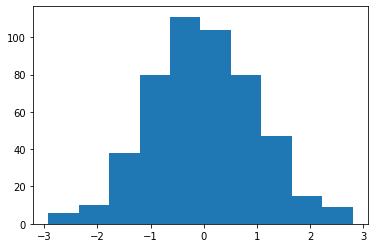

In [ ]:
plt.hist(z_group["Age"])

In [ ]:
fill_na_mean = lambda x : x.fillna(x.mean())

In [ ]:
double_group.transform(fill_na_mean)

,Height,Weight,Age,Income
0,196.343940,60.909064,40.451221,21385.958772
1,153.697110,48.005164,48.163870,19757.653998
2,146.713926,53.476714,31.144568,20279.476735
3,183.988501,71.785466,34.192437,19778.532678
4,179.805582,58.547234,32.501684,19346.337986
...,...,...,...,...
495,180.672252,51.029436,17.900334,20043.401932
496,151.602650,43.765061,27.617103,20241.297735
497,149.973149,67.190925,36.479521,19335.750899
498,163.669365,98.571932,35.257657,18888.280373


## Operaciones diversas muy útiles

In [ ]:
double_group.head(1)

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Rich,196.343940,60.909064,40.451221,21385.958772
1,Male,Middle Class,153.697110,48.005164,48.163870,19757.653998
3,Male,Rich,183.988501,71.785466,34.192437,19778.532678
4,Male,Poor,179.805582,58.547234,32.501684,19346.337986
5,Female,Poor,172.074560,28.192775,42.997942,21277.967078
7,Female,Middle Class,166.360472,33.332115,19.958657,19611.989916


In [ ]:
double_group.tail(1)

,Gender,Economic Status,Height,Weight,Age,Income
484,Female,Poor,237.863120,19.951759,49.066417,19810.325445
487,Male,Poor,227.539516,57.374036,25.997146,19157.948395
493,Female,Rich,169.567790,63.484671,29.763336,20821.406697
495,Female,Middle Class,180.672252,51.029436,17.900334,20043.401932
498,Male,Rich,163.669365,98.571932,35.257657,18888.280373
499,Male,Middle Class,148.236420,90.327894,13.374767,19467.309309


In [ ]:
double_group.nth(32)

Height     Weight        Age        Income
Gender Economic Status                                                
Female Middle Class     110.180551  68.190065  49.949398  19487.156361
       Poor             158.853184  63.085928  25.005120  20216.239204
       Rich             162.750233  65.951638  40.062883  18023.726084
Male   Middle Class     161.936648  70.117613   4.067120  19697.088560
       Poor             158.631750  52.472696  24.187545  19964.779021
       Rich             171.473068  45.510527  47.831414  20692.308396

In [ ]:
double_group.nth(82)

Height     Weight        Age        Income
Gender Economic Status                                               
Male   Poor             179.93339  76.802942  21.885402  20715.359892
       Rich             164.70270  86.880958  26.744570  19193.082787

In [ ]:
data_sorted = data.sort_values(["Age", "Income"])

In [ ]:
data_sorted.head(10)

,Gender,Economic Status,Height,Weight,Age,Income
59,Female,Poor,219.118989,106.348681,-3.837400,21298.802624
148,Female,Middle Class,140.433589,88.161987,-3.010737,19892.145392
22,Female,Rich,220.042892,66.970892,-2.860013,18189.632418
154,Female,Middle Class,101.836328,78.121454,-2.139509,19793.479229
89,Male,Poor,193.682572,79.271949,-1.181704,21008.166187
259,Male,Rich,142.594132,67.007006,3.368029,20693.817605
209,Male,Middle Class,161.936648,70.117613,4.067120,19697.088560
299,Male,Poor,194.034042,52.824096,5.591800,21409.162676
402,Male,Middle Class,149.062605,52.035421,6.173861,21435.420795
354,Male,Poor,189.448738,78.337713,6.195454,21369.689456


In [ ]:
age_grouped = data_sorted.groupby("Gender")

In [ ]:
age_grouped.head(1)

,Gender,Economic Status,Height,Weight,Age,Income
59,Female,Poor,219.118989,106.348681,-3.837400,21298.802624
89,Male,Poor,193.682572,79.271949,-1.181704,21008.166187


In [ ]:
age_grouped.tail(1)

,Gender,Economic Status,Height,Weight,Age,Income
423,Male,Poor,165.152608,61.613466,59.082634,20577.920332
492,Female,Middle Class,173.475638,52.248953,64.993034,20516.979828


# Conjunto de entrenamiento y conjunto de testing

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("/content/drive/My Drive/Curso Machine Learning con Python/datasets/customer-churn-model/Customer Churn Model.txt")

In [ ]:
len(data)

3333

## Dividir utilizando la distribución normal

In [ ]:
a = np.random.randn(len(data))

(array([  1.,  14.,  29.,  84., 111., 123.,  85.,  36.,   9.,   8.]),
 array([-3.19536083, -2.56704791, -1.93873498, -1.31042206, -0.68210914,
        -0.05379622,  0.5745167 ,  1.20282963,  1.83114255,  2.45945547,
         3.08776839]),
 <a list of 10 Patch objects>)

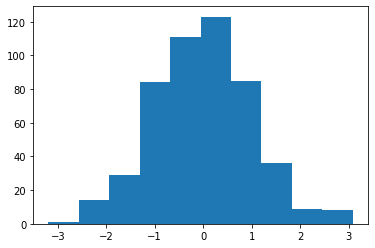

In [ ]:
plt.hist(a)

In [ ]:
check = (a<0.75) # No es el 75% de los datos, son los números que son < 0.75!!!

In [ ]:
check

array([False,  True,  True,  True,  True,  True,  True, False,  True,
        True, False,  True,  True, False,  True,  True,  True,  True,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True, False,  True, False,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
       False,  True, False,  True,  True,  True,  True,  True, False,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True, False,
       False, False,  True, False,  True,  True, False, False,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

(array([108.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 392.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 10 Patch objects>)

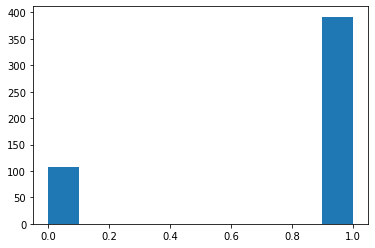

In [ ]:
plt.hist(check.astype(int))#Ha cambiado en la versión 3.7 de python y necesita hacer un cast de bool a entero

In [ ]:
training = data[check]
testing = data[~check]

In [ ]:
len(training)

392

In [ ]:
len(testing)

108

## Con la libreria sklearn

In [ ]:
from sklearn.model_selection import train_test_split# Ha cambiado en la 3.7 de Python

In [ ]:
train, test = train_test_split(data, test_size = 0.2)

In [ ]:
len(train)

400

In [ ]:
len(test)

100

## Usando una función de shuffle

In [ ]:
import numpy as np

In [ ]:
data.head()

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Rich,196.343940,60.909064,40.451221,21385.958772
1,Male,Middle Class,153.697110,48.005164,48.163870,19757.653998
2,Female,Rich,146.713926,53.476714,31.144568,20279.476735
3,Male,Rich,183.988501,71.785466,34.192437,19778.532678
4,Male,Poor,179.805582,58.547234,32.501684,19346.337986


In [ ]:
import sklearn

In [ ]:
data = sklearn.utils.shuffle(data)

In [ ]:
cut_id = int(0.75*len(data))
train_data = data[:cut_id]
test_data = data[cut_id+1:]

In [ ]:
len(train_data)

375

In [ ]:
len(test_data)

124